# 📊 HPO Results — Master Summary

Aggregates every saved best-param artifact under `notebooks/hpo/results/best/` (classical, deep learning, and quantum). Run the model notebooks first; this notebook only reads their outputs, so it can be re-run any time to refresh the leaderboard.


In [1]:
import sys
import os

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split("quantum-multiclass-classification")[0] + "quantum-multiclass-classification"
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data


Project root: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification


In [2]:
import json
import pandas as pd
from pathlib import Path

BEST_DIR = Path(project_root) / "notebooks" / "hpo" / "results" / "best"
files = sorted(BEST_DIR.glob("*.json"))
print(f"Found {len(files)} best-param artifacts in {BEST_DIR}")

rows = []
for fp in files:
    with open(fp, encoding="utf-8") as f:
        r = json.load(f)
    params_str = ' | '.join(f'{k}={v}' for k, v in r.get('params', {}).items())
    rows.append({
        'Category'       : r.get('category'),
        'Family'         : r.get('family', ''),
        'Circuit/Kernel' : r.get('circuit', ''),
        'Model'          : r.get('model'),
        'Accuracy'       : r.get('acc'),
        'Precision'      : r.get('prec'),
        'Recall'         : r.get('rec'),
        'F1-Score'       : r.get('f1'),
        'F1-Macro'       : r.get('f1_macro'),
        'ROC-AUC'        : r.get('roc'),
        'PR-AUC'         : r.get('pra'),
        'Log-Loss'       : r.get('loss'),
        'Selection'      : r.get('selection_score'),
        'Loss Gap'       : r.get('loss_gap'),
        'F1 Gap'         : r.get('f1_gap'),
        'Fit'            : r.get('fit_verdict', ''),
        'Train Acc'      : r.get('train_acc'),
        'Val Acc'        : r.get('val_acc'),
        'Fit Gap'        : r.get('fit_gap'),
        'Exec. Time (s)' : round(r['execution_time'], 2) if r.get('execution_time') is not None else None,
        'Best Params'    : params_str,
        'Artifact'       : fp.name,
    })

all_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print(f"Total evaluations: {len(all_df)}")
all_df.head()


Found 13 best-param artifacts in c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification\notebooks\hpo\results\best
Total evaluations: 13


,Category,Family,Circuit/Kernel,Model,Accuracy,Precision,Recall,F1-Score,F1-Macro,ROC-AUC,...,Selection,Loss Gap,F1 Gap,Fit,Train Acc,Val Acc,Fit Gap,Exec. Time (s),Best Params,Artifact
0,classical,,,CatBoost,0.8455±0.0032,0.8605±0.0028,0.8455±0.0032,0.8478±0.0033,0.8537±0.0045,0.9699±0.0037,...,0.4496,+0.0134,+0.0065,Generalized,0.8518,0.8455,0.0063,11.3800,iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=3 | bagging_temperature=0.5 | random_strength=1,catboost.json
1,dl,,,1D CNN,0.7065±0.0516,0.7368±0.0455,0.7065±0.0516,0.7103±0.0517,NaN,0.9171±0.0234,...,NaN,NaN,NaN,Overfit,0.8554,0.7065,0.1489,290.6100,"filters=[64, 128] | kernel_size=3 | dropout=0.2 | learning_rate=0.001 | batch_size=32 | epochs=100",cnn1d.json
2,dl,,,MLP,0.7156±0.0465,0.7533±0.0382,0.7156±0.0465,0.7227±0.0442,NaN,0.9185±0.0186,...,NaN,NaN,NaN,Overfit,0.8498,0.7156,0.1342,443.4900,"hidden_units=[128, 64, 32] | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100",mlp.json
3,quantum,original,circular,QSVC (circular),0.7853±0.0414,0.8129±0.0407,0.7853±0.0414,0.7908±0.0428,NaN,0.9465±0.0139,...,NaN,NaN,NaN,Overfit,0.9377,0.7853,0.1524,131.7600,C=0.1 | lambda_=0.1,quantum_original_circular_qsvc.json
4,quantum,original,full,QSVC (full),0.7841±0.0422,0.8121±0.0415,0.7841±0.0422,0.7898±0.0434,NaN,0.9483±0.0104,...,NaN,NaN,NaN,Overfit,0.9365,0.7841,0.1524,153.1300,C=0.1 | lambda_=0.1,quantum_original_full_qsvc.json


## Combined leaderboard


In [3]:
# Full ranking by selection score (penalized val log-loss, lower = better)
if len(all_df):
    ranked = all_df.sort_values('Selection', ascending=True).reset_index(drop=True)
    ranked.index += 1
    out = Path(project_root) / "notebooks" / "hpo" / "results" / "eval_all_final_hpo.csv"
    ranked.to_csv(out, index=True)
    print(f"✅ Saved combined ranking: {out}")
    display(ranked)
else:
    print("No artifacts yet — run the model notebooks first.")


✅ Saved combined ranking: c:\`Bioinformatics\quantum-gesang\quantum-multiclass-classification\notebooks\hpo\results\eval_all_final_hpo.csv


,Category,Family,Circuit/Kernel,Model,Accuracy,Precision,Recall,F1-Score,F1-Macro,ROC-AUC,...,Selection,Loss Gap,F1 Gap,Fit,Train Acc,Val Acc,Fit Gap,Exec. Time (s),Best Params,Artifact
1,classical,,,XGBoost GBTree,0.8763±0.0054,0.8872±0.0053,0.8763±0.0054,0.8783±0.0055,0.8828±0.0037,0.9791±0.0020,...,0.3394,+0.0406,+0.0213,Generalized,0.8968,0.8763,0.0206,18.1800,n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1,xgb_gbtree.json
2,classical,,,SVC RBF,0.8661±0.0043,0.8864±0.0035,0.8661±0.0043,0.8689±0.0044,0.8776±0.0037,0.9768±0.0023,...,0.3771,+0.0116,+0.0032,Generalized,0.8696,0.8661,0.0035,90.9300,C=1 | gamma=auto,svc_rbf.json
3,classical,,,CatBoost,0.8455±0.0032,0.8605±0.0028,0.8455±0.0032,0.8478±0.0033,0.8537±0.0045,0.9699±0.0037,...,0.4496,+0.0134,+0.0065,Generalized,0.8518,0.8455,0.0063,11.3800,iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=3 | bagging_temperature=0.5 | random_strength=1,catboost.json
4,classical,,,SVC Poly,0.7109±0.0082,0.7571±0.0107,0.7109±0.0082,0.7112±0.0076,0.7182±0.0136,0.9225±0.0045,...,0.6156,+0.0099,+0.0066,Underfit,0.7177,0.7109,0.0068,216.5000,C=1 | degree=3 | coef0=1.0 | gamma=auto,svc_poly.json
5,classical,,,XGBoost Dart,0.7718±0.0086,0.8031±0.0049,0.7718±0.0086,0.7759±0.0079,0.7606±0.0110,0.9387±0.0036,...,1.0504,+0.0109,+0.0121,Underfit,0.7816,0.7718,0.0098,34.8700,n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1 | rate_drop=0.1,xgb_dart.json
6,classical,,,SVC Linear,0.3555±0.0103,0.5123±0.0202,0.3555±0.0103,0.3364±0.0091,0.2968±0.0085,0.6731±0.0088,...,1.3837,+0.0014,+0.0031,Underfit,0.3566,0.3555,0.0012,438.7100,C=1,svc_linear.json
7,classical,,,SVC Sigmoid,0.1675±0.0068,0.3006±0.0344,0.1675±0.0068,0.1772±0.0088,0.1340±0.0064,0.6051±0.0095,...,1.4820,+0.0007,+0.0025,Underfit,0.1698,0.1675,0.0023,658.3800,C=0.01 | coef0=0.0,svc_sigmoid.json
8,dl,,,1D CNN,0.7065±0.0516,0.7368±0.0455,0.7065±0.0516,0.7103±0.0517,NaN,0.9171±0.0234,...,NaN,NaN,NaN,Overfit,0.8554,0.7065,0.1489,290.6100,"filters=[64, 128] | kernel_size=3 | dropout=0.2 | learning_rate=0.001 | batch_size=32 | epochs=100",cnn1d.json
9,dl,,,MLP,0.7156±0.0465,0.7533±0.0382,0.7156±0.0465,0.7227±0.0442,NaN,0.9185±0.0186,...,NaN,NaN,NaN,Overfit,0.8498,0.7156,0.1342,443.4900,"hidden_units=[128, 64, 32] | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100",mlp.json
10,quantum,original,circular,QSVC (circular),0.7853±0.0414,0.8129±0.0407,0.7853±0.0414,0.7908±0.0428,NaN,0.9465±0.0139,...,NaN,NaN,NaN,Overfit,0.9377,0.7853,0.1524,131.7600,C=0.1 | lambda_=0.1,quantum_original_circular_qsvc.json


## Per-category leaderboards


In [4]:
# Per-category leaderboards
for cat, g in all_df.groupby('Category'):
    print(f"\n===== {cat.upper()} ({len(g)} models) =====")
    gg = g.sort_values('Selection', ascending=True).reset_index(drop=True)
    gg.index += 1
    display(gg[['Family', 'Circuit/Kernel', 'Model', 'Accuracy', 'F1-Macro',
                'Log-Loss', 'Selection', 'Fit', 'Best Params']])



===== CLASSICAL (8 models) =====


,Family,Circuit/Kernel,Model,Accuracy,F1-Macro,Log-Loss,Selection,Fit,Best Params
1,,,XGBoost GBTree,0.8763±0.0054,0.8828±0.0037,0.3394±0.0148,0.3394,Generalized,n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1
2,,,SVC RBF,0.8661±0.0043,0.8776±0.0037,0.3771±0.0227,0.3771,Generalized,C=1 | gamma=auto
3,,,CatBoost,0.8455±0.0032,0.8537±0.0045,0.4496±0.0201,0.4496,Generalized,iterations=150 | depth=4 | learning_rate=0.1 | l2_leaf_reg=3 | bagging_temperature=0.5 | random_strength=1
4,,,SVC Poly,0.7109±0.0082,0.7182±0.0136,0.6156±0.0169,0.6156,Underfit,C=1 | degree=3 | coef0=1.0 | gamma=auto
5,,,XGBoost Dart,0.7718±0.0086,0.7606±0.0110,1.0504±0.0047,1.0504,Underfit,n_estimators=150 | learning_rate=0.1 | max_depth=4 | min_child_weight=1 | reg_lambda=1 | rate_drop=0.1
6,,,SVC Linear,0.3555±0.0103,0.2968±0.0085,1.3837±0.0172,1.3837,Underfit,C=1
7,,,SVC Sigmoid,0.1675±0.0068,0.1340±0.0064,1.4820±0.0097,1.4820,Underfit,C=0.01 | coef0=0.0
8,,,XGBoost GBTree No PCA,0.9038±0.0342,NaN,NaN,NaN,Overfit,n_estimators=500 | learning_rate=0.1 | max_depth=6 | min_child_weight=1 | reg_alpha=0 | reg_lambda=10 | gamma=0



===== DL (2 models) =====


,Family,Circuit/Kernel,Model,Accuracy,F1-Macro,Log-Loss,Selection,Fit,Best Params
1,,,1D CNN,0.7065±0.0516,NaN,NaN,NaN,Overfit,"filters=[64, 128] | kernel_size=3 | dropout=0.2 | learning_rate=0.001 | batch_size=32 | epochs=100"
2,,,MLP,0.7156±0.0465,NaN,NaN,NaN,Overfit,"hidden_units=[128, 64, 32] | dropout=0.2 | learning_rate=0.001 | batch_size=64 | epochs=100"



===== QUANTUM (3 models) =====


,Family,Circuit/Kernel,Model,Accuracy,F1-Macro,Log-Loss,Selection,Fit,Best Params
1,original,circular,QSVC (circular),0.7853±0.0414,NaN,NaN,NaN,Overfit,C=0.1 | lambda_=0.1
2,original,full,QSVC (full),0.7841±0.0422,NaN,NaN,NaN,Overfit,C=0.1 | lambda_=0.1
3,selisih,circular_selisih,QSVC (circular_selisih),0.7903±0.0442,NaN,NaN,NaN,Overfit,C=1 | lambda_=0.1


## Summary plots


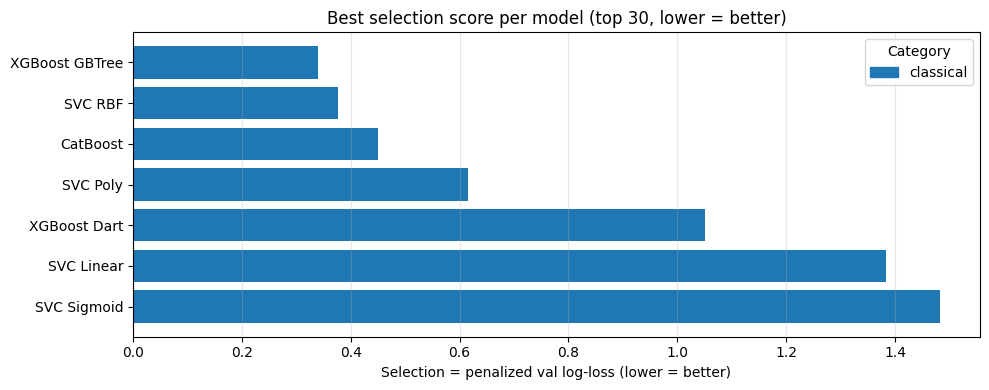

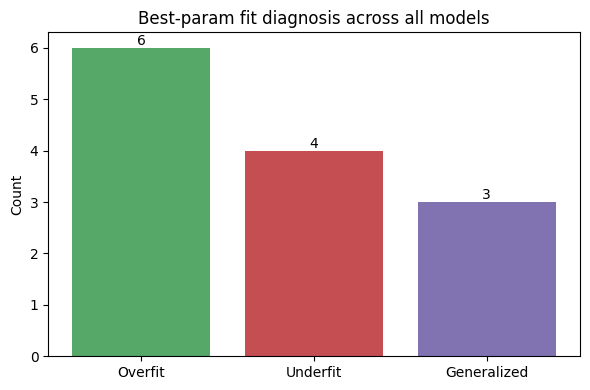

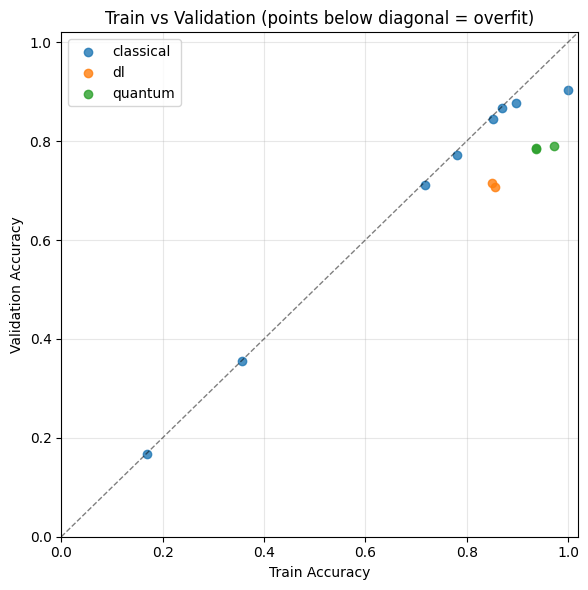

In [5]:
import matplotlib.pyplot as plt
import numpy as np

if len(all_df):
    # 1) Selection score per model (top 30 = lowest penalized log-loss), by category
    plot_df = all_df.dropna(subset=['Selection']).sort_values('Selection', ascending=False)
    if len(plot_df) > 30:
        plot_df = plot_df.tail(30)   # keep the 30 best (lowest selection)
    cats = plot_df['Category'].astype('category')
    palette = {c: clr for c, clr in zip(cats.cat.categories,
               plt.cm.tab10.colors)}
    colors = [palette[c] for c in plot_df['Category']]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.32 * len(plot_df))))
    ax.barh(plot_df['Model'], plot_df['Selection'].astype(float), color=colors)
    ax.set_xlabel('Selection = penalized val log-loss (lower = better)')
    ax.set_title('Best selection score per model (top 30, lower = better)')
    handles = [plt.Rectangle((0, 0), 1, 1, color=palette[c]) for c in palette]
    ax.legend(handles, list(palette.keys()), title='Category')
    ax.grid(axis='x', alpha=0.3)
    fig.tight_layout()
    fig.savefig(Path(project_root) / "notebooks" / "hpo" / "results" / "summary_selection.png",
                dpi=120, bbox_inches='tight')
    plt.show()

    # 2) Fit verdict counts
    fig, ax = plt.subplots(figsize=(6, 4))
    vc = all_df['Fit'].value_counts()
    ax.bar(vc.index, vc.values, color=['#55A868', '#C44E52', '#8172B2', '#999999'][:len(vc)])
    ax.set_title('Best-param fit diagnosis across all models')
    ax.set_ylabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(v), ha='center', va='bottom')
    fig.tight_layout()
    fig.savefig(Path(project_root) / "notebooks" / "hpo" / "results" / "summary_fit.png",
                dpi=120, bbox_inches='tight')
    plt.show()

    # 3) Train vs Val accuracy scatter (generalization view)
    sub = all_df.dropna(subset=['Train Acc', 'Val Acc'])
    if len(sub):
        fig, ax = plt.subplots(figsize=(6, 6))
        for c in sub['Category'].unique():
            s = sub[sub['Category'] == c]
            ax.scatter(s['Train Acc'].astype(float), s['Val Acc'].astype(float),
                       label=c, alpha=0.8)
        lim = [0.0, 1.02]
        ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('Train Accuracy'); ax.set_ylabel('Validation Accuracy')
        ax.set_title('Train vs Validation (points below diagonal = overfit)')
        ax.legend(); ax.grid(alpha=0.3)
        fig.tight_layout()
        fig.savefig(Path(project_root) / "notebooks" / "hpo" / "results" / "summary_trainval.png",
                    dpi=120, bbox_inches='tight')
        plt.show()
